#### Main Objective 
- The dataset chosen is of a ice cream sale dataset of a company who began it's business in 1991 and has expanded to multiple branches today.
- In this dataset, we are given two columns, the datetime of first day of each month from 2006 till 2023, and the total number of icecream sold that month
- From this dataset, we want to build three different time series models to forecast the ice cream sold for the next 6 months. 

#### Brief Description

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pmdarima as pm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")
# Change the current working directory to the specified path
os.chdir(r'C:\Users\raudhah.soffian\OneDrive - PETRONAS\Desktop\Project\Training\Devops\Training\IBM\Time_Series\data')

In [17]:
# Use pandas to read the CSV file 'icecream_sales.csv' into a DataFrame
df = pd.read_csv('icecream_sales.csv')
df.head()

,date,value
0,7/1/2006,350
1,8/1/2006,320
2,9/1/2006,330
3,10/1/2006,360
4,11/1/2006,360


- This dataset has 204 rows which can be read from df.info() below.
- All variables are in numerical (float64 or int64).

In [18]:
#Get summary of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    204 non-null    object
 1   value   204 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 3.3+ KB


#### Data Exploration, Cleaning, and Feature Engineering
- We want to check for any missing values. 
- This data has no missing values as shown below.

In [19]:
df.isnull().sum()

date     0
value    0
dtype: int64

- Transform **Date** column into a datetime object 
- Set **Date** as index

In [20]:
df['date'] = pd.to_datetime(df['date'])


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    204 non-null    datetime64[ns]
 1   value   204 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 3.3 KB


In [22]:
df.set_index('date', inplace=True)
df.head()

,value
date,
2006-07-01,350
2006-08-01,320
2006-09-01,330
2006-10-01,360
2006-11-01,360


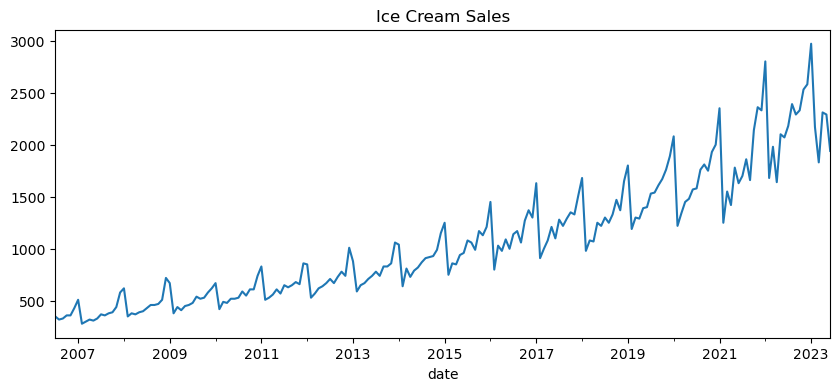

In [23]:
fig, ax = plt.subplots(figsize=(10,4), dpi=100)
df.plot(title='Ice Cream Sales', legend=False, ax=ax);

In [24]:
# Split into train and test set
train, test = df[:-24], df[-24:] # 2 years for test

1st Model: ARIMA

- Auto arima uses stepwise approach to search multiple combination of p,d,q parameters
- Choose the best model with least AIC

In [25]:
model_auto_arima = pm.auto_arima(df, start_p=0, start_q=0,
                      test='adf',       # use adftest to find optimal 'd'
                      max_p=4, max_q=4, # maximum p and q
                      m=1,              # frequency of series
                      d=None,           # let model determine 'd'
                      seasonal=False,   # No Seasonality
                      start_P=0, 
                      D=0, 
                      trace=True,
                      error_action='ignore',  
                      suppress_warnings=True, 
                      stepwise=True)

print(model_auto_arima.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=3481.611, Time=0.14 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=2792.071, Time=0.03 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=3271.359, Time=0.08 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=inf, Time=0.11 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=2752.857, Time=0.18 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=2744.321, Time=0.19 sec
 ARIMA(3,0,1)(0,0,0)[0]             : AIC=2745.659, Time=0.34 sec
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=2750.061, Time=0.31 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=2746.969, Time=0.19 sec
 ARIMA(3,0,0)(0,0,0)[0]             : AIC=inf, Time=0.17 sec
 ARIMA(3,0,2)(0,0,0)[0]             : AIC=2737.424, Time=0.47 sec
 ARIMA(4,0,2)(0,0,0)[0]             : AIC=inf, Time=0.59 sec
 ARIMA(3,0,3)(0,0,0)[0]             : AIC=inf, Time=0.51 sec
 ARIMA(2,0,3)(0,0,0)[0]             : AIC=2738.198, Time=0.48 sec
 ARIMA(4,0,1)(0,0,0)[0]             : AIC=2755.515, T

In [26]:
model_arima = ARIMA(train, order=(3, 0, 2))  
result_arima = model_arima.fit()

In [27]:
print(result_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  180
Model:                 ARIMA(3, 0, 2)   Log Likelihood               -1170.315
Date:                Tue, 28 May 2024   AIC                           2354.631
Time:                        00:31:33   BIC                           2376.981
Sample:                    07-01-2006   HQIC                          2363.693
                         - 06-01-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        922.6891    721.023      1.280      0.201    -490.491    2335.869
ar.L1          0.3551      0.188      1.892      0.059      -0.013       0.723
ar.L2          0.9953      0.033     30.580      0.0

Text(0.5, 1.0, 'Train, Test and Predicted Test using ARIMA')

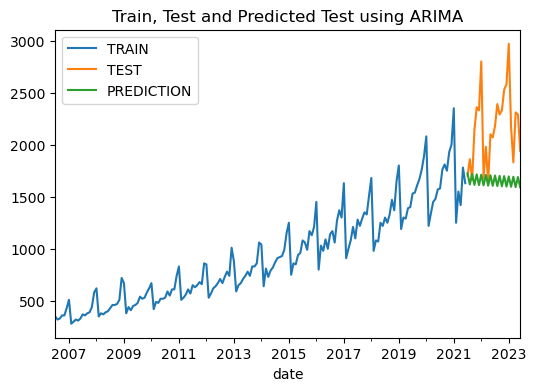

In [28]:
start=len(train)
end=len(train)+len(test)-1
arima_predictions = result_arima.predict(start=start, end=end, dynamic=False, typ='levels').rename('ARIMA Predictions')

train['value'].plot(legend=True,label='TRAIN')
test['value'].plot(legend=True,label='TEST',figsize=(6,4))
arima_predictions.plot(legend=True,label='PREDICTION')
plt.title('Train, Test and Predicted Test using ARIMA')

SARIMA

In [29]:
# Seasonal - fit stepwise auto-ARIMA
smodel = pm.auto_arima(df, start_p=1, start_q=1,
                         test='adf',
                         max_p=3, max_q=3, m=12, #m=12 for monthly dataset
                         start_P=0, seasonal=True, #set seasonal=True
                         d=None, D=1, trace=True, #set D=1
                         error_action='ignore',  
                         suppress_warnings=True, 
                         stepwise=True)

smodel.summary()

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[12] intercept   : AIC=2304.250, Time=1.40 sec
 ARIMA(0,0,0)(0,1,0)[12] intercept   : AIC=2392.949, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[12] intercept   : AIC=2364.938, Time=0.69 sec
 ARIMA(0,0,1)(0,1,1)[12] intercept   : AIC=2380.219, Time=0.65 sec
 ARIMA(0,0,0)(0,1,0)[12]             : AIC=2525.894, Time=0.04 sec
 ARIMA(1,0,1)(0,1,0)[12] intercept   : AIC=2328.586, Time=0.37 sec
 ARIMA(1,0,1)(1,1,1)[12] intercept   : AIC=2309.120, Time=1.88 sec
 ARIMA(1,0,1)(0,1,2)[12] intercept   : AIC=2306.324, Time=3.17 sec
 ARIMA(1,0,1)(1,1,0)[12] intercept   : AIC=2312.626, Time=2.39 sec
 ARIMA(1,0,1)(1,1,2)[12] intercept   : AIC=inf, Time=4.99 sec
 ARIMA(1,0,0)(0,1,1)[12] intercept   : AIC=2363.294, Time=1.01 sec
 ARIMA(2,0,1)(0,1,1)[12] intercept   : AIC=2299.306, Time=3.13 sec
 ARIMA(2,0,1)(0,1,0)[12] intercept   : AIC=2324.623, Time=0.83 sec
 ARIMA(2,0,1)(1,1,1)[12] intercept   : AIC=2301.020, Time=3.18 sec
 ARIMA(2,0,1)(0,1,2)[12]

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                    y   No. Observations:                  204
Model:             SARIMAX(3, 0, 0)x(0, 1, [1], 12)   Log Likelihood               -1143.052
Date:                              Tue, 28 May 2024   AIC                           2298.103
Time:                                      00:32:52   BIC                           2317.648
Sample:                                  07-01-2006   HQIC                          2306.019
                                       - 06-01-2023                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     16.5851      9.689      1.712      0.087      -2.406      35.576
ar.L1          0.0956      0.043      2.213      0.027       0.011       0.180
ar.L2          0.4090      0.035     11.721      0.000       0.341       0.477
ar.L3          0.3550      0.055      6.484      0.000       0.248       0.462
ma.S.L12      -0.4642      0.059     -7.814      0.000      -0.581      -0.348
sigma2      8504.8478    568.187     14.968      0.000    7391.223    9618.473
===================================================================================
Ljung-Box (L1) (Q):                   0.03   Jarque-Bera (JB):               130.03
Prob(Q):                              0.86   Prob(JB):                         0.00
Heteroskedasticity (H):              12.32   Skew:                             0.32
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.98
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [30]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [31]:
model_sarima = SARIMAX(train, order=(3, 0, 0), seasonal_order=(0, 1, 1, 12))
result_sarima = model_sarima.fit()

In [32]:
print(result_sarima.summary())

                                      SARIMAX Results                                       
Dep. Variable:                                value   No. Observations:                  180
Model:             SARIMAX(3, 0, 0)x(0, 1, [1], 12)   Log Likelihood                -937.517
Date:                              Tue, 28 May 2024   AIC                           1885.033
Time:                                      00:32:53   BIC                           1900.653
Sample:                                  07-01-2006   HQIC                          1891.373
                                       - 06-01-2021                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1451      0.074      1.956      0.050      -0.000       0.290
ar.L2          0.51

Text(0.5, 1.0, 'Train, Test and Predicted Test using SARIMA')

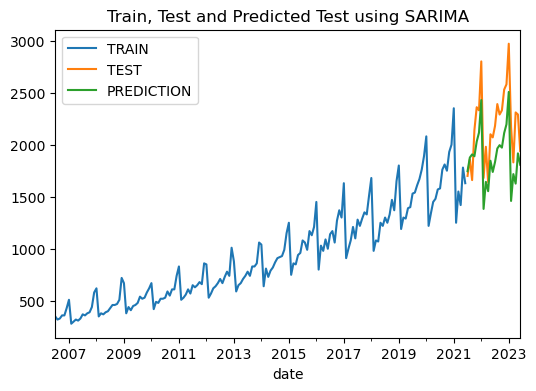

In [33]:
start=len(train)
end=len(train)+len(test)-1
sarima_predictions = result_sarima.predict(start=start, end=end, dynamic=False, typ='levels').rename('SARIMA Predictions')

train['value'].plot(legend=True,label='TRAIN')
test['value'].plot(legend=True,label='TEST',figsize=(6,4))
sarima_predictions.plot(legend=True,label='PREDICTION')
plt.title('Train, Test and Predicted Test using SARIMA')

Holts Winter

In [34]:
from statsmodels.tsa.seasonal import seasonal_decompose
# single exponential smoothing
from statsmodels.tsa.holtwinters import SimpleExpSmoothing   
# double and triple exponential smoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

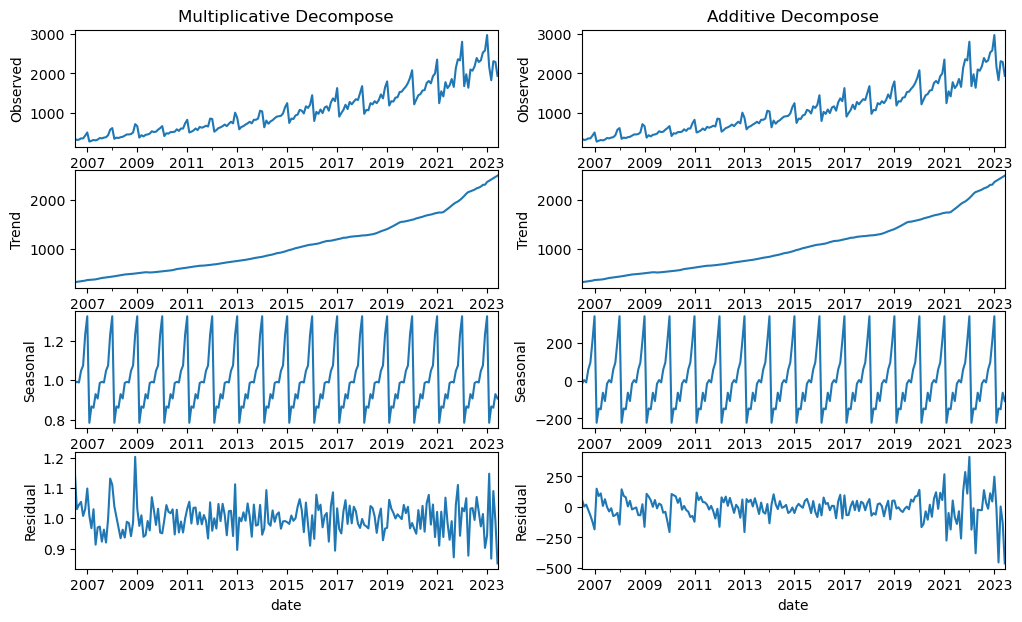

In [35]:
# Multiplicative Decomposition 
result_mul = seasonal_decompose(df['value'], model='multiplicative', extrapolate_trend='freq')
#extrapolate_trend='freq' takes care of any missing values in the trend and residuals at the beginning of the series.

# Additive Decomposition
result_add = seasonal_decompose(df['value'], model='additive', extrapolate_trend='freq')

def plotseasonal(res, axes, title):
    axes[0].set_title(title, fontsize=12)
    res.observed.plot(ax=axes[0], legend=False)
    axes[0].set_ylabel('Observed', fontsize=10)
    
    res.trend.plot(ax=axes[1], legend=False)
    axes[1].set_ylabel('Trend', fontsize=10)
    
    res.seasonal.plot(ax=axes[2], legend=False)
    axes[2].set_ylabel('Seasonal', fontsize=10)
    
    res.resid.plot(ax=axes[3], legend=False)
    axes[3].set_ylabel('Residual', fontsize=10)

# Plot

fig, axes = plt.subplots(ncols=2, nrows=4, sharex=False, figsize=(12,7))
plotseasonal(result_mul, axes[:,0], title='Multiplicative Decompose')
plotseasonal(result_add, axes[:,1], title='Additive Decompose')

# Residuals of the additive decomposition has some pattern left over. 
# The multiplicative decomposition looks quite random throughout which is good.
# Multiplicative decomposition should be preferred for this series.

In [36]:
# Set the frequency of the date time index as Monthly start as indicated by the data
df.index.freq = 'MS'
# Set the value of Alpha and define m (Time Period)
m = 12
alpha = 1/(2*m)

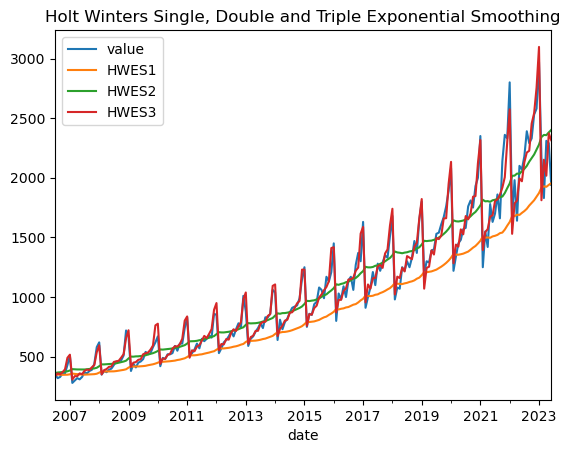

In [37]:
df['HWES1'] = SimpleExpSmoothing(df['value']).fit(smoothing_level=alpha,optimized=False,use_brute=True).fittedvalues
df['HWES2'] = ExponentialSmoothing(df['value'],trend='mul').fit().fittedvalues
df['HWES3'] = ExponentialSmoothing(df['value'],trend='mul',seasonal='mul',seasonal_periods=12).fit().fittedvalues
df[['value','HWES1','HWES2','HWES3']].plot(title='Holt Winters Single, Double and Triple Exponential Smoothing');


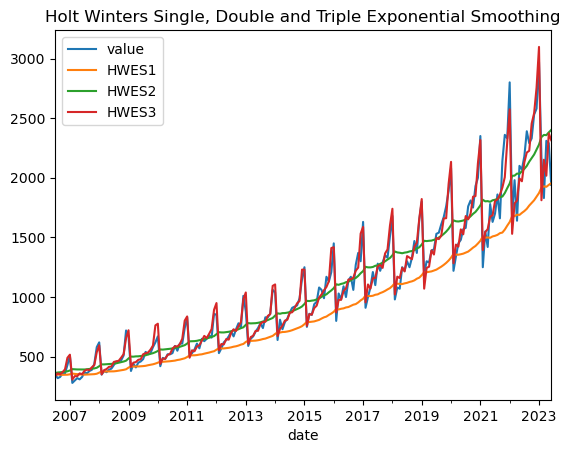

In [38]:
df[['value','HWES1','HWES2','HWES3']].plot(title='Holt Winters Single, Double and Triple Exponential Smoothing');

In [39]:
holtswinter_model = ExponentialSmoothing(train['value'],trend='mul',seasonal='mul',seasonal_periods=12).fit()
holtswinter_predictions = holtswinter_model.forecast(24)

In [40]:
df['arima'] = arima_predictions
df['sarima'] = sarima_predictions
df['holtswinter'] = holtswinter_predictions
df['train'] = train['value']
df['test'] = test['value']

In [41]:
df

,value,HWES1,HWES2,HWES3,arima,sarima,holtswinter,train,test
date,,,,,,,,,
2006-07-01,350,350.000000,363.999311,336.477918,NaN,NaN,NaN,350.0,NaN
2006-08-01,320,350.000000,367.412253,360.305495,NaN,NaN,NaN,320.0,NaN
2006-09-01,330,348.750000,368.977305,352.232560,NaN,NaN,NaN,330.0,NaN
2006-10-01,360,347.968750,370.897491,370.541903,NaN,NaN,NaN,360.0,NaN
2006-11-01,360,348.470052,374.285236,393.660353,NaN,NaN,NaN,360.0,NaN
...,...,...,...,...,...,...,...,...,...
2023-02-01,2170,1917.858646,2341.345501,1811.635872,1595.218827,1459.513412,1583.101602,NaN,2170.0
2023-03-01,1830,1928.364536,2359.380349,2151.296421,1692.259297,1717.199541,1834.041599,NaN,1830.0
2023-04-01,2310,1924.266014,2357.351882,2017.321141,1592.944212,1626.162412,1814.609586,NaN,2310.0


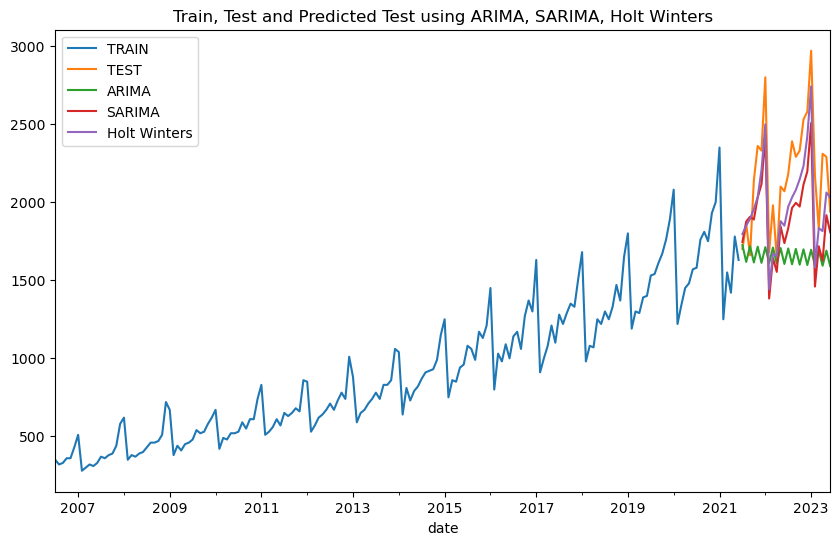

In [42]:
df['train'].plot(legend=True,label='TRAIN')
df['test'].plot(legend=True,label='TEST',figsize=(10,6))
df['arima'].plot(legend=True,label='ARIMA')
df['sarima'].plot(legend=True,label='SARIMA')
df['holtswinter'].plot(legend=True,label='Holt Winters')
plt.title('Train, Test and Predicted Test using ARIMA, SARIMA, Holt Winters');

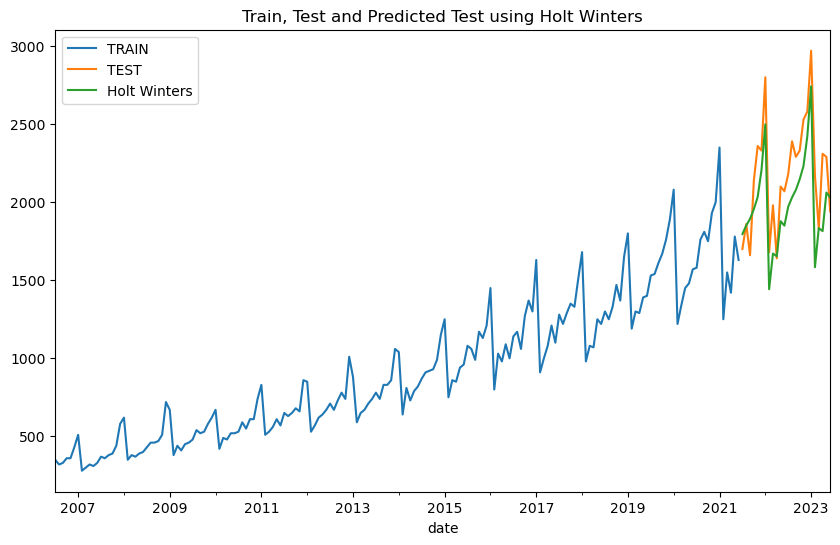

In [43]:
df['train'].plot(legend=True,label='TRAIN')
df['test'].plot(legend=True,label='TEST',figsize=(10,6))
# df['arima'].plot(legend=True,label='ARIMA')
# df['sarima'].plot(legend=True,label='SARIMA')
df['holtswinter'].plot(legend=True,label='Holt Winters')
plt.title('Train, Test and Predicted Test using Holt Winters');

In [44]:
def calculate_metrics(actual, prediction):
    mape = mean_absolute_percentage_error(actual, prediction) * 100
    mae = mean_absolute_error(actual, prediction)
    mse = mean_squared_error(actual, prediction)

    metrics_df = pd.DataFrame({
        'MAPE': [mape],
        'MAE': [mae],
        'MSE': [mse]
    })

    return metrics_df

In [45]:
model_list = ['arima', 'sarima', 'holtswinter']
df_result = df[['arima', 'sarima', 'holtswinter', 'test']].copy().dropna(axis=0)
metrics_df = pd.DataFrame()
actual = df_result['test']
for model_name in model_list:
    prediction = df_result[model_name]
    model_metrics = calculate_metrics(actual, prediction)
    model_metrics.index = [model_name]
    metrics_df = pd.concat([metrics_df, model_metrics]).sort_values(by='MAPE')

metrics_df.round(2)

,MAPE,MAE,MSE
holtswinter,10.05,222.09,67836.61
sarima,13.97,311.95,124982.29
arima,22.33,524.60,386016.72


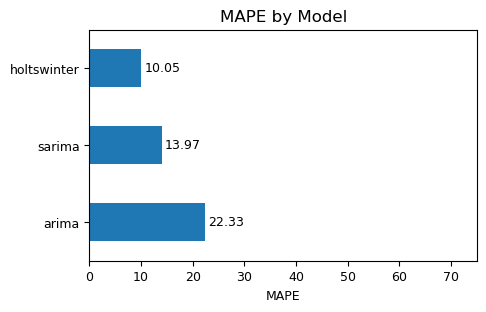

In [46]:
ax = metrics_df['MAPE'].sort_values(ascending=False).plot(kind='barh', figsize=(5, 3))  # Decrease the height of the figure
ax.set_title('MAPE by Model')
ax.set_xlabel('MAPE', fontsize=9)  # Set x label size
# Set axis label size
ax.tick_params(axis='both', labelsize=9)
ax.set_xlim([0, 75])

for p in ax.patches:
    ax.annotate(format(p.get_width(), '.2f'), 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha = 'center', 
                va = 'center', 
                xytext = (15, 0), 
                fontsize= 9,
                textcoords = 'offset points')

plt.show()